In [1]:
import pandas as pd
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("synthetic_fraud_dataset.csv")


In [2]:
df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


In [46]:
df['transaction_id']

0       9608
1        456
2       4747
3       6934
4       1646
        ... 
9995    1076
9996    4995
9997    3485
9998    7922
9999    6451
Name: transaction_id, Length: 10000, dtype: int64

In [3]:
df.describe()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000
max,9999.00000,999.000000,11628.213881,23.000000,0.998737,0.999603,1.000000


## Korelasi Amount ↔ Fraud

### Hipotesis
H0 : Tidak ada hubungan antara jumlah transaksi (Amount) dengan Fraud  
H1 : Ada hubungan antara jumlah transaksi (Amount) dengan Fraud

In [8]:
corr, p = pearsonr(df['amount'], df['is_fraud'])

print("korelasi: {}".format(corr))
print("p-value: {}".format(p))

korelasi: 0.6384350549014357
p-value: 0.0


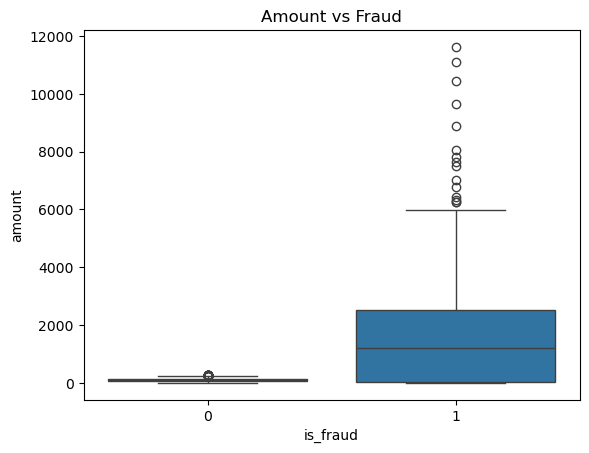

In [15]:
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.title("Amount vs Fraud")
plt.show()

Nilai korelasi Pearson antara variabel amount dan is_fraud adalah sebesar 0.63 dengan p-value < 0.05. Hal ini menunjukkan terdapat hubungan positif dan signifikan secara statistik antara jumlah transaksi dan fraud. Artinya, transaksi dengan jumlah lebih tinggi cenderung memiliki kemungkinan fraud lebih tinggi. Gambar boxplot menunjukkan bahwa transaksi yang terindikasi fraud memiliki nilai amount yang cenderung jauh lebih besar dibandingkan transaksi normal. Hal ini terlihat dari median, rentang data, serta outliers yang secara umum lebih tinggi pada kelompok fraud. Dengan demikian, jumlah transaksi dapat menjadi indikator penting dalam mendeteksi fraud.

## Korelasi Hour ↔ Fraud

### Hipotesis
H0 : Tidak ada hubungan antara waktu transaksi dengan Fraud  
H1 : Ada hubungan antara waktu transaksi dengan Fraud


In [17]:
corr, p = pearsonr(df['hour'], df['is_fraud'])
print("korelasi: {}".format(corr))
print("p-value: {}".format(p))

korelasi: -0.18144775886967898
p-value: 9.143599695090788e-75


Korelasi Pearson antara variabel hour dan is_fraud memperoleh nilai sebesar -0.18 dengan p-value < 0.05. Hal ini menunjukkan adanya hubungan negatif yang sangat lemah namun signifikan secara statistik antara waktu transaksi dengan fraud. Artinya, transaksi yang terjadi pada jam lebih awal memiliki kecenderungan fraud yang sedikit lebih tinggi, meskipun pengaruh waktu terhadap fraud tidak terlalu kuat.

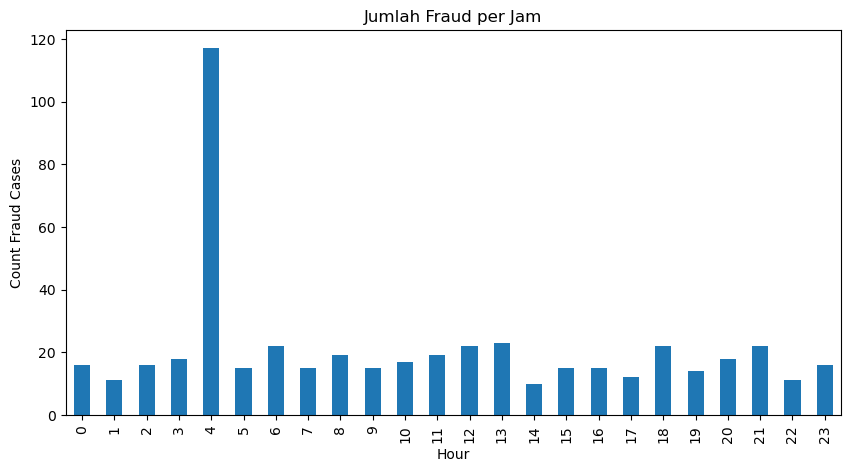

In [30]:
fraud_hour = df[df['is_fraud'] == 1]['hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
fraud_hour.plot(kind='bar')
plt.title("Jumlah Fraud per Jam")
plt.xlabel("Hour")
plt.ylabel("Count Fraud Cases")
plt.show()


## Korelasi device_risk_score ↔  is_fraud
### Hipotesis

H0 : Tidak ada hubungan antara variabel device_risk_score dengan kejadian Fraud

H1 : Ada hubungan antara variabel device_risk_score dengan kejadian Fraud

In [31]:
corr, p = pearsonr(df['device_risk_score'], df['is_fraud'])
print("korelasi: {}".format(corr))
print("p-value: {}".format(p))

korelasi: 0.8719893034448556
p-value: 0.0


Korelasi Pearson antara device_risk_score dan is_fraud sebesar 0.8719893034448556 dengan p-value < 0.05. Artinya terdapat hubungan positif antara skor risiko device dengan kejadian fraud. Semakin tinggi device_risk_score, semakin besar kemungkinan transaksi tersebut merupakan fraud. Namun kekuatan hubungan korelasinya termasuk lemah/sedang.

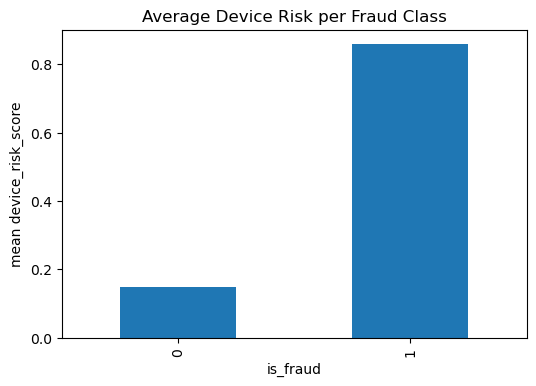

In [37]:
plt.figure(figsize=(6,4))
df.groupby('is_fraud')['device_risk_score'].mean().plot(kind='bar')
plt.title("Average Device Risk per Fraud Class")
plt.xlabel("is_fraud")
plt.ylabel("mean device_risk_score")
plt.show()


## 2. Korelasi ip_risk_score ↔ is_fraud
### Hipotesis

H0 : Tidak ada hubungan antara variabel ip_risk_score dengan kejadian Fraud

H1 : Ada hubungan antara variabel ip_risk_score dengan kejadian Fraud

In [32]:
corr, p = pearsonr(df['ip_risk_score'], df['is_fraud'])
print("korelasi: {}".format(corr))
print("p-value: {}".format(p))

korelasi: 0.8707379856846702
p-value: 0.0


Korelasi Pearson antara ip_risk_score dan is_fraud <…>  sebesar 0.8707379856846702 dengan p-value < 0.05. Artinya menunjukkan terdapat hubungan positif antara resiko IP dan fraud. Namun tetap perlu diingat bahwa hubungan korelasi tidak selalu berarti kausalitas.

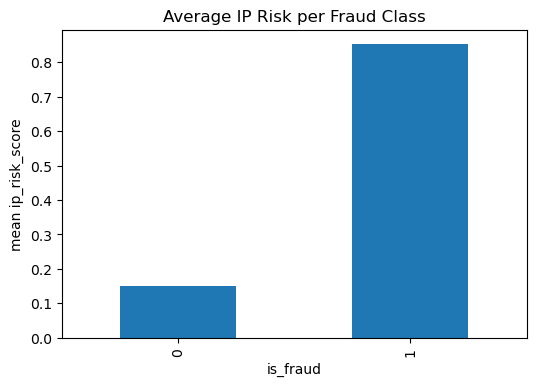

In [38]:
plt.figure(figsize=(6,4))
df.groupby('is_fraud')['ip_risk_score'].mean().plot(kind='bar')
plt.title("Average IP Risk per Fraud Class")
plt.xlabel("is_fraud")
plt.ylabel("mean ip_risk_score")
plt.show()

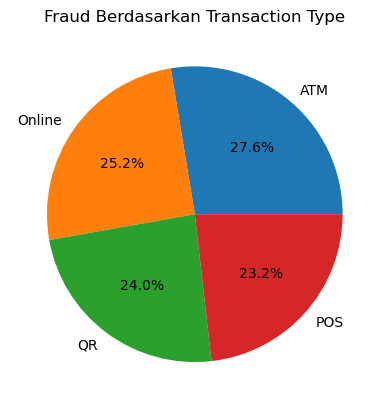

In [40]:
trans_banyak_fraud = df[df.is_fraud==1]['transaction_type'].value_counts()

plt.pie(trans_banyak_fraud.values, labels=trans_banyak_fraud.index, autopct='%1.1f%%')
plt.title("Fraud Berdasarkan Transaction Type")
plt.show()

Terlihat paling banyak fraud terjadi di ATM

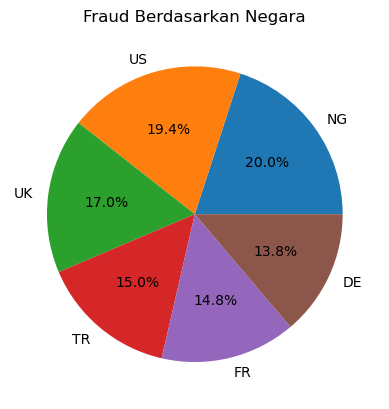

In [42]:
country_banyak_fraud = df[df.is_fraud==1]['country'].value_counts()

plt.pie(country_banyak_fraud.values, labels=country_banyak_fraud.index, autopct='%1.1f%%')
plt.title("Fraud Berdasarkan Negara")
plt.show()

fraud paling banyak terjadi di negara NG

In [43]:
var = 'skill akselerator bootcamp'
var[2:-2]

'ill akselerator bootca'